# PodcastFillers After-Training / Inference Notebook

Notebook ini **tidak melakukan training ulang**. Isinya hanya untuk load model hasil training dan melakukan inference.

Output yang disediakan:
- Full label 13 kelas: `Uh`, `Um`, `You know`, `Other`, `Like`, `Words`, `Repetitions`, `Breath`, `Laughter`, `Music`, `Agree`, `Noise`, `Overlap`
- Binary summary: `filler` / `non_filler`
- 5-class interview summary: `filler`, `speech`, `repetition`, `delivery_cue`, `audio_noise`

Buka VS Code di folder project:

```text
D:\KULIAH\Andro sems 6\Capstone\Filter Word Detection
```

Struktur yang diasumsikan:

```text
Filter Word Detection
├── models
│   ├── best_podcastfillers_full_label.keras
│   └── podcastfillers_full_label_metadata.json
├── PodcastFillers.csv
└── extracted
    └── PodcastFillers
        └── audio
            └── clip_wav
```


In [1]:
# =========================
# IMPORTS
# =========================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)

tf.config.optimizer.set_jit(False)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Could not set memory growth:", e)


TensorFlow: 2.21.0
GPUs: []


In [2]:
# =========================
# PATH CONFIG
# =========================

PROJECT_DIR = Path.cwd()

MODEL_PATH = PROJECT_DIR / "models" / "best_podcastfillers_full_label_finetuned.keras"

# Jika model hasil fine-tuning lebih bagus, gunakan ini:
# MODEL_PATH = PROJECT_DIR / "models" / "best_podcastfillers_full_label_finetuned.keras"

METADATA_PATH = PROJECT_DIR / "models" / "podcastfillers_full_label_metadata.json"

CSV_PATH = PROJECT_DIR / "PodcastFillers.csv"
AUDIO_ROOT = PROJECT_DIR / "extracted" / "PodcastFillers" / "audio" / "clip_wav"

print("PROJECT_DIR :", PROJECT_DIR)
print("MODEL exists:", MODEL_PATH.exists(), MODEL_PATH)
print("META exists :", METADATA_PATH.exists(), METADATA_PATH)
print("CSV exists  :", CSV_PATH.exists(), CSV_PATH)
print("AUDIO exists:", AUDIO_ROOT.exists(), AUDIO_ROOT)

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model tidak ditemukan: {MODEL_PATH}")

if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Metadata tidak ditemukan: {METADATA_PATH}")


PROJECT_DIR : c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection
MODEL exists: True c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\models\best_podcastfillers_full_label_finetuned.keras
META exists : True c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\models\podcastfillers_full_label_metadata.json
CSV exists  : True c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\PodcastFillers.csv
AUDIO exists: True c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\extracted\PodcastFillers\audio\clip_wav


In [3]:
# =========================
# LOAD METADATA
# =========================

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

FULL_LABELS = metadata.get("full_labels", [
    "Uh", "Um", "You know", "Other", "Like",
    "Words", "Repetitions", "Breath", "Laughter", "Music",
    "Agree", "Noise", "Overlap"
])

FILLER_LABELS = metadata.get("filler_labels", ["Uh", "Um", "You know", "Other", "Like"])
NON_FILLER_LABELS = metadata.get("non_filler_labels", [
    "Words", "Repetitions", "Breath", "Laughter", "Music", "Agree", "Noise", "Overlap"
])

label_to_id = {label: idx for idx, label in enumerate(FULL_LABELS)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

NUM_CLASSES = len(FULL_LABELS)

SAMPLE_RATE = int(metadata.get("sample_rate", 16000))
CLIP_SECONDS = float(metadata.get("clip_seconds", 1.0))
TARGET_SAMPLES = int(SAMPLE_RATE * CLIP_SECONDS)

NUM_MELS = int(metadata.get("num_mels", 64))
FRAME_LENGTH = int(metadata.get("frame_length", 400))
FRAME_STEP = int(metadata.get("frame_step", 160))
FFT_LENGTH = int(metadata.get("fft_length", 512))

LOWER_EDGE_HZ = 80.0
UPPER_EDGE_HZ = 7600.0
NUM_SPECTROGRAM_BINS = FFT_LENGTH // 2 + 1

print("NUM_CLASSES:", NUM_CLASSES)
print("FULL_LABELS:", FULL_LABELS)
print("FILLER_LABELS:", FILLER_LABELS)
print("SAMPLE_RATE:", SAMPLE_RATE)


NUM_CLASSES: 13
FULL_LABELS: ['Uh', 'Um', 'You know', 'Other', 'Like', 'Words', 'Repetitions', 'Breath', 'Laughter', 'Music', 'Agree', 'Noise', 'Overlap']
FILLER_LABELS: ['Uh', 'Um', 'You know', 'Other', 'Like']
SAMPLE_RATE: 16000


In [4]:
# =========================
# CUSTOM OBJECTS UNTUK LOAD MODEL
# =========================

class WeightedSparseCategoricalCrossEntropy(keras.losses.Loss):
    def __init__(self, class_weight=None, name="weighted_sparse_categorical_crossentropy", **kwargs):
        super().__init__(name=name, **kwargs)
        self.class_weight = class_weight

    def call(self, y_true, logits):
        y_true = tf.cast(y_true, tf.int32)
        loss = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=y_true,
            logits=logits
        )
        return tf.reduce_mean(loss)


class MacroF1Score(keras.metrics.Metric):
    def __init__(self, num_classes=13, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = self.add_weight(name="tp", shape=(num_classes,), initializer="zeros")
        self.fp = self.add_weight(name="fp", shape=(num_classes,), initializer="zeros")
        self.fn = self.add_weight(name="fn", shape=(num_classes,), initializer="zeros")

    def update_state(self, y_true, logits, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.argmax(logits, axis=-1, output_type=tf.int32)
        y_pred = tf.reshape(y_pred, [-1])

        y_true_oh = tf.one_hot(y_true, depth=self.num_classes, dtype=tf.float32)
        y_pred_oh = tf.one_hot(y_pred, depth=self.num_classes, dtype=tf.float32)

        self.tp.assign_add(tf.reduce_sum(y_true_oh * y_pred_oh, axis=0))
        self.fp.assign_add(tf.reduce_sum((1.0 - y_true_oh) * y_pred_oh, axis=0))
        self.fn.assign_add(tf.reduce_sum(y_true_oh * (1.0 - y_pred_oh), axis=0))

    def result(self):
        precision = self.tp / (self.tp + self.fp + 1e-7)
        recall = self.tp / (self.tp + self.fn + 1e-7)
        f1 = 2.0 * precision * recall / (precision + recall + 1e-7)
        return tf.reduce_mean(f1)

    def reset_state(self):
        self.tp.assign(tf.zeros_like(self.tp))
        self.fp.assign(tf.zeros_like(self.fp))
        self.fn.assign(tf.zeros_like(self.fn))


In [5]:
# =========================
# LOAD MODEL
# =========================

model = keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "WeightedSparseCategoricalCrossEntropy": WeightedSparseCategoricalCrossEntropy,
        "MacroF1Score": MacroF1Score,
    },
    compile=False
)

print("Model loaded:", MODEL_PATH)
model.summary()


Model loaded: c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\models\best_podcastfillers_full_label_finetuned.keras


Model: "podcastfillers_cnn_bilstm_full_label"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ logmel_input (InputLayer)       │ (None, 100, 64, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 64, 32)    │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 64, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 100, 64, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 50, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 25, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_to_sequence (Reshape)       │ (None, 12, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 12, 192)        │       860,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_logits (Dense)            │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,104,045 (4.21 MB)

 Trainable params: 1,103,597 (4.21 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
# =========================
# FIXED FEATURE EXTRACTION FOR TF.DATA
# =========================

with tf.device("/CPU:0"):
    MEL_WEIGHT_MATRIX = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=NUM_MELS,
        num_spectrogram_bins=NUM_SPECTROGRAM_BINS,
        sample_rate=SAMPLE_RATE,
        lower_edge_hertz=LOWER_EDGE_HZ,
        upper_edge_hertz=UPPER_EDGE_HZ
    )


# =========================
# FIX PATHLIB ERROR + TF.DATA SAFE FEATURE EXTRACTION
# =========================

def load_wav_fixed_1sec(audio_path):
    # Supaya aman untuk:
    # 1. input pathlib.Path / WindowsPath saat inference biasa
    # 2. input tf.Tensor string saat dipakai di tf.data
    if isinstance(audio_path, (str, Path)):
        audio_path = tf.constant(str(audio_path), dtype=tf.string)

    audio_bytes = tf.io.read_file(audio_path)
    audio, sr = tf.audio.decode_wav(audio_bytes, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    # Jangan pakai sr.numpy() karena fungsi ini juga dipakai di tf.data graph mode.
    tf.debugging.assert_equal(
        sr,
        tf.constant(SAMPLE_RATE, dtype=sr.dtype),
        message="Sample rate audio tidak sama dengan SAMPLE_RATE. Convert dulu ke WAV 16 kHz."
    )

    audio = tf.cast(audio, tf.float32)
    audio_len = tf.shape(audio)[0]

    audio = tf.cond(
        audio_len < TARGET_SAMPLES,
        lambda: tf.pad(audio, [[0, TARGET_SAMPLES - audio_len]]),
        lambda: audio[:TARGET_SAMPLES]
    )

    audio = audio / (tf.reduce_max(tf.abs(audio)) + 1e-6)
    return audio


def waveform_to_logmel(audio):
    stft = tf.signal.stft(
        audio,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=FFT_LENGTH,
        pad_end=True
    )

    spectrogram = tf.abs(stft)
    power_spectrogram = tf.square(spectrogram)
    mel_spectrogram = tf.matmul(power_spectrogram, MEL_WEIGHT_MATRIX)
    log_mel = tf.math.log(mel_spectrogram + 1e-6)

    log_mel = (log_mel - tf.reduce_mean(log_mel)) / (tf.math.reduce_std(log_mel) + 1e-6)
    log_mel = tf.expand_dims(log_mel, axis=-1)

    return log_mel


def preprocess_audio_path(audio_path):
    audio = load_wav_fixed_1sec(audio_path)
    features = waveform_to_logmel(audio)
    features = tf.expand_dims(features, axis=0)
    return features


def preprocess_test_example(audio_path, label):
    # Untuk dataset batch evaluation, jangan expand batch dimension di sini.
    audio = load_wav_fixed_1sec(audio_path)
    features = waveform_to_logmel(audio)
    label = tf.cast(label, tf.int32)
    return features, label


print("Fixed feature extraction ready.")

Fixed feature extraction ready.


In [11]:
# =========================
# LABEL MAPPING
# =========================

INTERVIEW_CLASSES = [
    "filler",
    "speech",
    "repetition",
    "delivery_cue",
    "audio_noise",
]

interview_label_to_id = {label: idx for idx, label in enumerate(INTERVIEW_CLASSES)}
interview_id_to_label = {idx: label for label, idx in interview_label_to_id.items()}


def summarize_label_for_interview(label_name):
    if label_name in ["Uh", "Um", "You know", "Other", "Like"]:
        return "filler"

    if label_name == "Words":
        return "speech"

    if label_name == "Repetitions":
        return "repetition"

    if label_name in ["Breath", "Laughter", "Agree"]:
        return "delivery_cue"

    if label_name in ["Music", "Noise", "Overlap"]:
        return "audio_noise"

    return "audio_noise"


def label_name_to_binary(label_name):
    return "filler" if label_name in FILLER_LABELS else "non_filler"


filler_ids = [label_to_id[label] for label in FILLER_LABELS if label in label_to_id]

print("Mapping ready.")
print("filler_ids:", filler_ids)


Mapping ready.
filler_ids: [0, 1, 2, 3, 4]


In [12]:
# =========================
# PREDICT SINGLE 1-SECOND AUDIO CLIP
# =========================

def predict_audio_clip(audio_path, top_k=5):
    features = preprocess_audio_path(audio_path)

    logits = model(features, training=False)
    probs = tf.nn.softmax(logits, axis=-1).numpy().reshape(-1)

    pred_id = int(np.argmax(probs))
    pred_label = id_to_label[pred_id]

    top_indices = np.argsort(probs)[::-1][:top_k]

    top_predictions = []
    for idx in top_indices:
        label_name = id_to_label[int(idx)]
        top_predictions.append({
            "label": label_name,
            "probability": float(probs[int(idx)]),
            "binary_summary": label_name_to_binary(label_name),
            "interview_summary": summarize_label_for_interview(label_name),
        })

    return {
        "audio_path": str(audio_path),
        "prediction_id": pred_id,
        "prediction_label": pred_label,
        "confidence": float(probs[pred_id]),
        "binary_summary": label_name_to_binary(pred_label),
        "interview_summary": summarize_label_for_interview(pred_label),
        "filler_probability_sum": float(np.sum(probs[filler_ids])),
        "top_predictions": top_predictions,
    }


def print_prediction_result(result):
    print("Audio             :", result["audio_path"])
    print("Full label pred   :", result["prediction_label"])
    print("Confidence        :", round(result["confidence"], 4))
    print("Binary summary    :", result["binary_summary"])
    print("Interview summary :", result["interview_summary"])
    print("Filler prob sum   :", round(result["filler_probability_sum"], 4))
    print("\nTop predictions:")
    for item in result["top_predictions"]:
        print(
            f"- {item['label']:12s} | "
            f"prob={item['probability']:.4f} | "
            f"binary={item['binary_summary']:10s} | "
            f"summary={item['interview_summary']}"
        )


print("Single clip prediction ready.")


Single clip prediction ready.


In [13]:
# =========================
# TEST SINGLE CLIP FROM DATASET
# =========================

if CSV_PATH.exists() and AUDIO_ROOT.exists():
    df = pd.read_csv(CSV_PATH)
    df["audio_path"] = df.apply(
        lambda row: AUDIO_ROOT / str(row["clip_split_subset"]) / str(row["clip_name"]),
        axis=1
    )
    df["audio_exists"] = df["audio_path"].apply(lambda p: p.exists())
    sample_df = df[df["audio_exists"]].reset_index(drop=True)

    if len(sample_df) > 0:
        sample_row = sample_df.iloc[0]
        print("Actual full label:", sample_row.get("label_full_vocab", "N/A"))
        print("Clip split       :", sample_row.get("clip_split_subset", "N/A"))
        result = predict_audio_clip(sample_row["audio_path"])
        print_prediction_result(result)
    else:
        print("Tidak ada audio sample yang ditemukan.")
else:
    print("CSV/AUDIO_ROOT tidak tersedia. Lewati test sample.")


Actual full label: Agree
Clip split       : extra
Audio             : c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\extracted\PodcastFillers\audio\clip_wav\extra\00000.wav
Full label pred   : Agree
Confidence        : 0.9169
Binary summary    : non_filler
Interview summary : delivery_cue
Filler prob sum   : 0.0103

Top predictions:
- Agree        | prob=0.9169 | binary=non_filler | summary=delivery_cue
- Words        | prob=0.0305 | binary=non_filler | summary=speech
- Noise        | prob=0.0218 | binary=non_filler | summary=audio_noise
- Repetitions  | prob=0.0112 | binary=non_filler | summary=repetition
- Um           | prob=0.0068 | binary=filler     | summary=filler


Test rows: 10398

Test label distribution:
label_full_vocab
Uh             2598
Um             2446
Words          1441
Repetitions     852
Music           827
Breath          732
Laughter        579
Agree           476
Noise           207
Overlap         152
Other            40
You know         33
Like             15
Name: count, dtype: int64

FULL LABEL 13-CLASS TEST RESULTS
Accuracy   : 0.735237545681862
Macro F1   : 0.5417231218679702
Weighted F1: 0.7360728408157732

Classification report - Full Label:
              precision    recall  f1-score   support

          Uh       0.87      0.81      0.84      2598
          Um       0.90      0.92      0.91      2446
    You know       0.19      0.73      0.30        33
       Other       0.04      0.15      0.07        40
        Like       0.04      0.07      0.05        15
       Words       0.60      0.24      0.35      1441
 Repetitions       0.44      0.49      0.47       852
      Breath       0.83      0.90      0.86       732
 

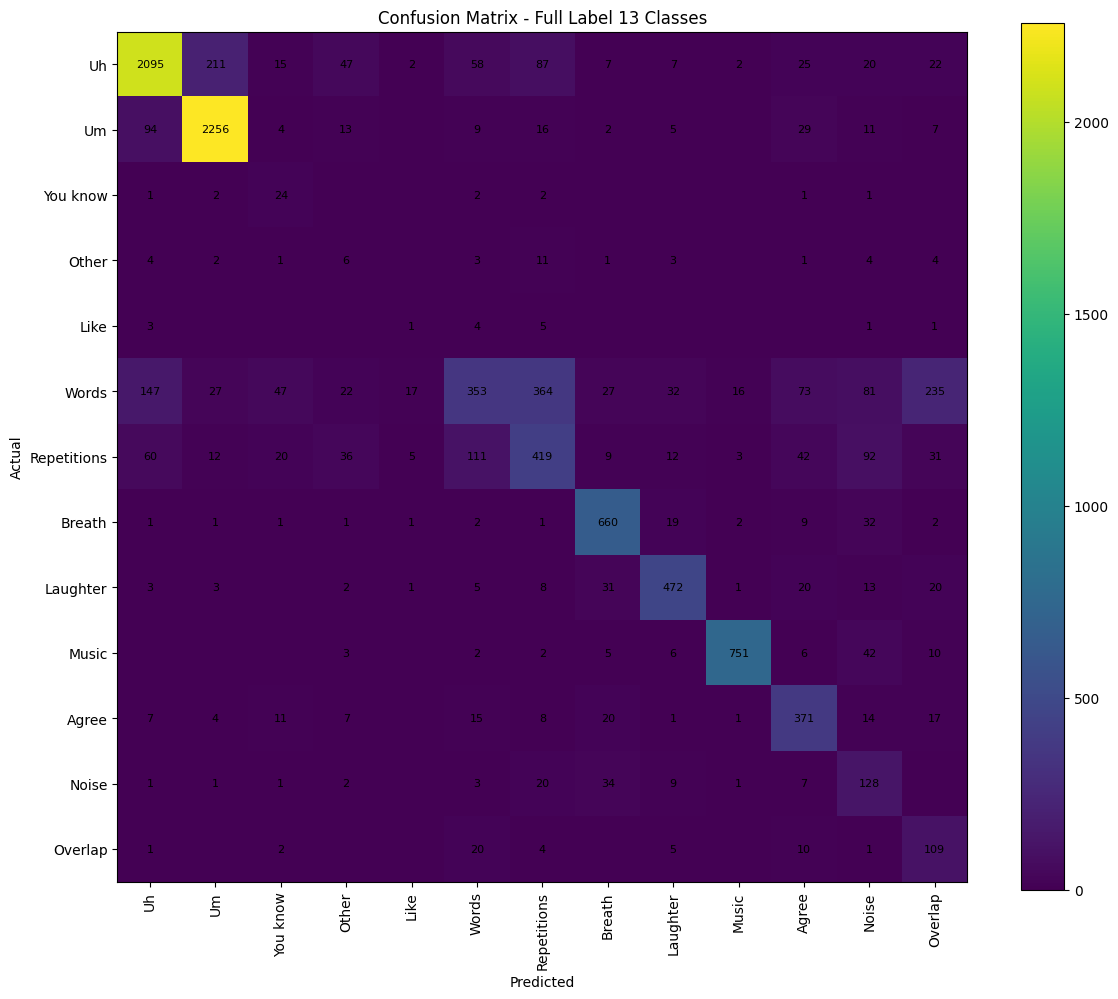


BINARY SUMMARY TEST RESULTS
Accuracy   : 0.9232544720138488
Macro F1   : 0.923253447007759
Weighted F1: 0.9232570615029179

Classification report - Binary Summary:
              precision    recall  f1-score   support

  non_filler       0.93      0.92      0.92      5266
      filler       0.91      0.93      0.92      5132

    accuracy                           0.92     10398
   macro avg       0.92      0.92      0.92     10398
weighted avg       0.92      0.92      0.92     10398



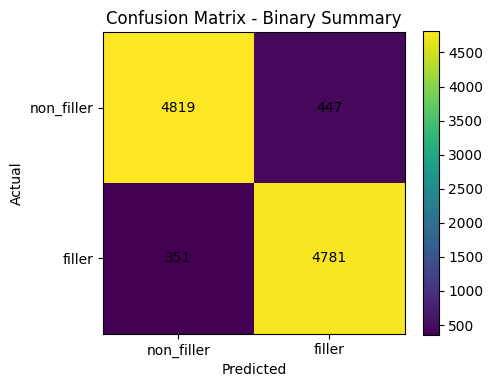


5-CLASS INTERVIEW SUMMARY TEST RESULTS
Accuracy   : 0.788420850163493
Macro F1   : 0.664143945128643
Weighted F1: 0.7720431101666775

Classification report - 5-Class Interview Summary:
              precision    recall  f1-score   support

      filler       0.91      0.93      0.92      5132
      speech       0.60      0.24      0.35      1441
  repetition       0.44      0.49      0.47       852
delivery_cue       0.82      0.90      0.86      1787
 audio_noise       0.62      0.88      0.73      1186

    accuracy                           0.79     10398
   macro avg       0.68      0.69      0.66     10398
weighted avg       0.78      0.79      0.77     10398



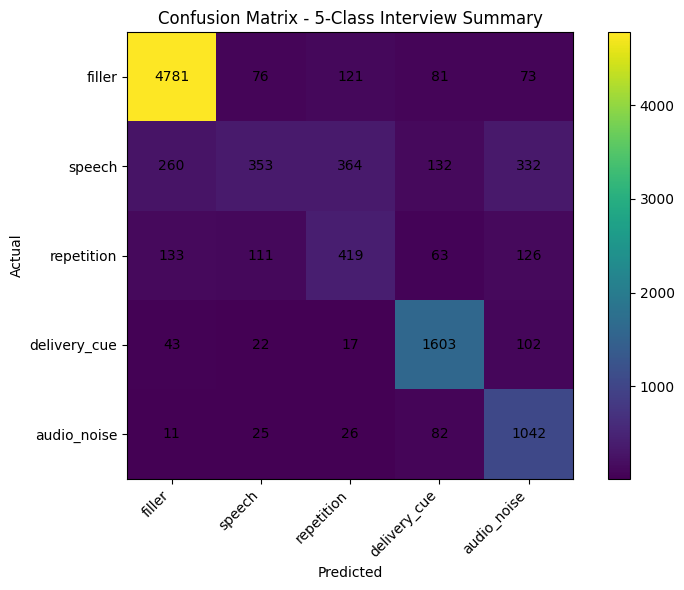


Saved test predictions to: test_predictions_summary.csv


,clip_name,true_full_label,pred_full_label,pred_confidence,true_binary,pred_binary,true_interview_summary,pred_interview_summary,audio_path
0,00003.wav,Breath,Breath,0.992791,non_filler,non_filler,delivery_cue,delivery_cue,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
1,00012.wav,Words,Overlap,0.794162,non_filler,non_filler,speech,audio_noise,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
2,00018.wav,Breath,Breath,0.999166,non_filler,non_filler,delivery_cue,delivery_cue,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
3,00025.wav,Um,Um,0.773926,filler,filler,filler,filler,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
4,00032.wav,Um,Um,0.992159,filler,filler,filler,filler,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
5,00037.wav,Breath,Breath,0.998789,non_filler,non_filler,delivery_cue,delivery_cue,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
6,00050.wav,Uh,Um,0.645007,filler,filler,filler,filler,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
7,00063.wav,Uh,Uh,0.891789,filler,filler,filler,filler,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
8,00066.wav,Um,Um,0.918633,filler,filler,filler,filler,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
9,00097.wav,Uh,Uh,0.476542,filler,filler,filler,filler,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...


In [14]:
# =========================
# TEST SET EVALUATION
# FULL LABEL + BINARY + 5-CLASS SUMMARY
# =========================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support
)

# =========================
# LOAD TEST DATA ONLY
# =========================

if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV tidak ditemukan: {CSV_PATH}")

if not AUDIO_ROOT.exists():
    raise FileNotFoundError(f"AUDIO_ROOT tidak ditemukan: {AUDIO_ROOT}")

test_df = pd.read_csv(CSV_PATH)

# Gunakan full label valid saja
test_df = test_df[test_df["label_full_vocab"].isin(FULL_LABELS)].copy()

# Gunakan episode split test agar evaluasi sesuai split resmi
test_df = test_df[test_df["episode_split_subset"] == "test"].copy()

# Path audio tetap berdasarkan clip_split_subset karena lokasi file fisik
test_df["audio_path"] = test_df.apply(
    lambda row: AUDIO_ROOT / str(row["clip_split_subset"]) / str(row["clip_name"]),
    axis=1
)

test_df["audio_exists"] = test_df["audio_path"].apply(lambda p: p.exists())
test_df = test_df[test_df["audio_exists"]].reset_index(drop=True)

test_df["label_id"] = test_df["label_full_vocab"].map(label_to_id).astype("int32")

print("Test rows:", len(test_df))
print("\nTest label distribution:")
print(test_df["label_full_vocab"].value_counts())


# =========================
# MAKE TEST DATASET
# =========================

BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_test_example(audio_path, label):
    features = preprocess_audio_path(audio_path)
    features = tf.squeeze(features, axis=0)
    label = tf.cast(label, tf.int32)
    return features, label


test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["audio_path"].astype(str).values,
        test_df["label_id"].astype("int32").values,
    )
)

test_ds = test_ds.map(
    preprocess_test_example,
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


# =========================
# PREDICT TEST SET
# =========================

def predict_dataset_full_label(model, dataset):
    all_true = []
    all_pred = []
    all_probs = []

    for features_batch, labels_batch in dataset:
        logits = model(features_batch, training=False)
        probs = tf.nn.softmax(logits, axis=-1).numpy()
        preds = np.argmax(probs, axis=1)

        all_true.extend(labels_batch.numpy().astype(int).tolist())
        all_pred.extend(preds.astype(int).tolist())
        all_probs.append(probs)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    all_probs = np.concatenate(all_probs, axis=0)

    return all_true, all_pred, all_probs


y_true, y_pred, y_prob = predict_dataset_full_label(model, test_ds)


# =========================
# FULL LABEL 13-CLASS REPORT
# =========================

full_acc = accuracy_score(y_true, y_pred)
full_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
full_weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("\n" + "=" * 60)
print("FULL LABEL 13-CLASS TEST RESULTS")
print("=" * 60)
print("Accuracy   :", full_acc)
print("Macro F1   :", full_macro_f1)
print("Weighted F1:", full_weighted_f1)

print("\nClassification report - Full Label:")
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=FULL_LABELS,
    zero_division=0
))

full_cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(12, 10))
plt.imshow(full_cm)
plt.title("Confusion Matrix - Full Label 13 Classes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(NUM_CLASSES), FULL_LABELS, rotation=90)
plt.yticks(range(NUM_CLASSES), FULL_LABELS)

for i in range(full_cm.shape[0]):
    for j in range(full_cm.shape[1]):
        if full_cm[i, j] > 0:
            plt.text(j, i, str(full_cm[i, j]), ha="center", va="center", fontsize=8)

plt.colorbar()
plt.tight_layout()
plt.show()


# =========================
# BINARY SUMMARY REPORT
# =========================

filler_ids_set = set(filler_ids)

y_true_binary = np.array([
    1 if int(label_id) in filler_ids_set else 0
    for label_id in y_true
])

y_pred_binary = np.array([
    1 if int(label_id) in filler_ids_set else 0
    for label_id in y_pred
])

binary_acc = accuracy_score(y_true_binary, y_pred_binary)
binary_macro_f1 = f1_score(y_true_binary, y_pred_binary, average="macro", zero_division=0)
binary_weighted_f1 = f1_score(y_true_binary, y_pred_binary, average="weighted", zero_division=0)

print("\n" + "=" * 60)
print("BINARY SUMMARY TEST RESULTS")
print("=" * 60)
print("Accuracy   :", binary_acc)
print("Macro F1   :", binary_macro_f1)
print("Weighted F1:", binary_weighted_f1)

print("\nClassification report - Binary Summary:")
print(classification_report(
    y_true_binary,
    y_pred_binary,
    labels=[0, 1],
    target_names=["non_filler", "filler"],
    zero_division=0
))

binary_cm = confusion_matrix(
    y_true_binary,
    y_pred_binary,
    labels=[0, 1]
)

plt.figure(figsize=(5, 4))
plt.imshow(binary_cm)
plt.title("Confusion Matrix - Binary Summary")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["non_filler", "filler"])
plt.yticks([0, 1], ["non_filler", "filler"])

for i in range(binary_cm.shape[0]):
    for j in range(binary_cm.shape[1]):
        plt.text(j, i, str(binary_cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


# =========================
# 5-CLASS INTERVIEW SUMMARY REPORT
# =========================

def full_label_id_to_interview_id(label_id):
    full_label = id_to_label[int(label_id)]
    summary_label = summarize_label_for_interview(full_label)
    return interview_label_to_id[summary_label]


y_true_interview = np.array([
    full_label_id_to_interview_id(label_id)
    for label_id in y_true
])

y_pred_interview = np.array([
    full_label_id_to_interview_id(label_id)
    for label_id in y_pred
])

interview_acc = accuracy_score(y_true_interview, y_pred_interview)
interview_macro_f1 = f1_score(y_true_interview, y_pred_interview, average="macro", zero_division=0)
interview_weighted_f1 = f1_score(y_true_interview, y_pred_interview, average="weighted", zero_division=0)

print("\n" + "=" * 60)
print("5-CLASS INTERVIEW SUMMARY TEST RESULTS")
print("=" * 60)
print("Accuracy   :", interview_acc)
print("Macro F1   :", interview_macro_f1)
print("Weighted F1:", interview_weighted_f1)

print("\nClassification report - 5-Class Interview Summary:")
print(classification_report(
    y_true_interview,
    y_pred_interview,
    labels=list(range(len(INTERVIEW_CLASSES))),
    target_names=INTERVIEW_CLASSES,
    zero_division=0
))

interview_cm = confusion_matrix(
    y_true_interview,
    y_pred_interview,
    labels=list(range(len(INTERVIEW_CLASSES)))
)

plt.figure(figsize=(8, 6))
plt.imshow(interview_cm)
plt.title("Confusion Matrix - 5-Class Interview Summary")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(
    range(len(INTERVIEW_CLASSES)),
    INTERVIEW_CLASSES,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(INTERVIEW_CLASSES)),
    INTERVIEW_CLASSES
)

for i in range(interview_cm.shape[0]):
    for j in range(interview_cm.shape[1]):
        plt.text(j, i, str(interview_cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


# =========================
# OPTIONAL: SAVE TEST PREDICTIONS
# =========================

test_pred_df = test_df.copy()
test_pred_df["true_full_label"] = [id_to_label[int(x)] for x in y_true]
test_pred_df["pred_full_label"] = [id_to_label[int(x)] for x in y_pred]
test_pred_df["pred_confidence"] = np.max(y_prob, axis=1)

test_pred_df["true_binary"] = [
    "filler" if int(x) in filler_ids_set else "non_filler"
    for x in y_true
]

test_pred_df["pred_binary"] = [
    "filler" if int(x) in filler_ids_set else "non_filler"
    for x in y_pred
]

test_pred_df["true_interview_summary"] = [
    interview_id_to_label[int(x)]
    for x in y_true_interview
]

test_pred_df["pred_interview_summary"] = [
    interview_id_to_label[int(x)]
    for x in y_pred_interview
]

output_test_pred_csv = "test_predictions_summary.csv"
test_pred_df.to_csv(output_test_pred_csv, index=False)

print("\nSaved test predictions to:", output_test_pred_csv)
display(test_pred_df[[
    "clip_name",
    "true_full_label",
    "pred_full_label",
    "pred_confidence",
    "true_binary",
    "pred_binary",
    "true_interview_summary",
    "pred_interview_summary",
    "audio_path"
]].head(20))

In [15]:
# =========================
# PLOT LOG-MEL AUDIO
# =========================

def plot_logmel(audio_path):
    audio = load_wav_fixed_1sec(audio_path)
    log_mel = waveform_to_logmel(audio)

    plt.figure(figsize=(10, 4))
    plt.imshow(tf.squeeze(log_mel, axis=-1).numpy().T, aspect="auto", origin="lower")
    plt.title(f"Log-Mel Spectrogram\n{audio_path}")
    plt.xlabel("Time frames")
    plt.ylabel("Mel bins")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


# Contoh:
# plot_logmel(r"path\to\audio.wav")


In [ ]:
# =========================
# LONG INTERVIEW AUDIO INFERENCE
# =========================
# Audio panjang akan dipotong menjadi window 1 detik.
# Audio harus WAV 16 kHz.
#
# Convert dengan ffmpeg:
# ffmpeg -i input.mp3 -ac 1 -ar 16000 output_16k.wav

def load_long_wav(audio_path):
    audio_bytes = tf.io.read_file(str(audio_path))
    audio, sr = tf.audio.decode_wav(audio_bytes, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    if int(sr.numpy()) != SAMPLE_RATE:
        raise ValueError(
            f"Sample rate harus {SAMPLE_RATE}, tetapi audio memiliki sample rate {int(sr.numpy())}. "
            "Convert dulu ke WAV 16 kHz."
        )

    audio = tf.cast(audio, tf.float32)
    audio = audio / (tf.reduce_max(tf.abs(audio)) + 1e-6)
    return audio


def predict_long_audio(audio_path, window_seconds=1.0, hop_seconds=0.5, batch_size=64):
    audio_path = str(audio_path)
    audio = load_long_wav(audio_path)

    window_samples = int(window_seconds * SAMPLE_RATE)
    hop_samples = int(hop_seconds * SAMPLE_RATE)

    total_samples = int(audio.shape[0])
    duration = total_samples / SAMPLE_RATE

    clips = []
    times = []

    start = 0
    while start < total_samples:
        end = start + window_samples
        clip = audio[start:end]

        if tf.shape(clip)[0] < window_samples:
            clip = tf.pad(clip, [[0, window_samples - tf.shape(clip)[0]]])

        feature = waveform_to_logmel(clip)
        clips.append(feature)
        times.append((start / SAMPLE_RATE, min(end / SAMPLE_RATE, duration)))

        start += hop_samples

    if len(clips) == 0:
        raise ValueError("Audio kosong atau tidak dapat diproses.")

    features = tf.stack(clips, axis=0)

    all_probs = []
    for i in range(0, len(features), batch_size):
        batch = features[i:i + batch_size]
        logits = model(batch, training=False)
        probs = tf.nn.softmax(logits, axis=-1).numpy()
        all_probs.append(probs)

    all_probs = np.concatenate(all_probs, axis=0)
    pred_ids = np.argmax(all_probs, axis=1)

    timeline = []

    for idx, pred_id in enumerate(pred_ids):
        pred_label = id_to_label[int(pred_id)]
        start_time, end_time = times[idx]

        timeline.append({
            "start_time": float(start_time),
            "end_time": float(end_time),
            "prediction_id": int(pred_id),
            "prediction_label": pred_label,
            "confidence": float(all_probs[idx, pred_id]),
            "binary_summary": label_name_to_binary(pred_label),
            "interview_summary": summarize_label_for_interview(pred_label),
            "filler_probability_sum": float(np.sum(all_probs[idx, filler_ids])),
        })

    total_windows = len(timeline)

    summary_counts = {
        cls: sum(1 for item in timeline if item["interview_summary"] == cls)
        for cls in INTERVIEW_CLASSES
    }

    full_label_counts = {
        label: sum(1 for item in timeline if item["prediction_label"] == label)
        for label in FULL_LABELS
    }

    filler_windows = summary_counts["filler"]

    return {
        "audio_path": audio_path,
        "duration_seconds": float(duration),
        "window_seconds": window_seconds,
        "hop_seconds": hop_seconds,
        "total_windows": total_windows,
        "filler_windows": filler_windows,
        "filler_rate": filler_windows / max(total_windows, 1),
        "summary_counts": summary_counts,
        "full_label_counts": full_label_counts,
        "timeline": timeline,
    }


print("Long audio inference ready.")


Long audio inference ready.


In [ ]:
# =========================
# SUMMARY & FEEDBACK
# =========================

def print_long_audio_summary(result, show_timeline_top=20):
    print("Audio duration :", round(result["duration_seconds"], 2), "seconds")
    print("Total windows  :", result["total_windows"])
    print("Filler windows :", result["filler_windows"])
    print("Filler rate    :", round(result["filler_rate"], 4))

    print("\n5-Class interview summary counts:")
    for cls, count in result["summary_counts"].items():
        rate = count / max(result["total_windows"], 1)
        print(f"- {cls:12s}: {count:5d} ({rate:.2%})")

    print("\nFull label counts:")
    for label, count in result["full_label_counts"].items():
        if count > 0:
            rate = count / max(result["total_windows"], 1)
            print(f"- {label:12s}: {count:5d} ({rate:.2%})")

    print(f"\nTimeline sample first {show_timeline_top}:")
    for item in result["timeline"][:show_timeline_top]:
        print(
            f"{item['start_time']:7.2f}s - {item['end_time']:7.2f}s | "
            f"{item['prediction_label']:12s} | "
            f"{item['interview_summary']:12s} | "
            f"conf={item['confidence']:.3f} | "
            f"filler_prob={item['filler_probability_sum']:.3f}"
        )


def generate_fluency_feedback(result):
    filler_rate = result["filler_rate"]
    repetition_rate = result["summary_counts"].get("repetition", 0) / max(result["total_windows"], 1)
    noise_rate = result["summary_counts"].get("audio_noise", 0) / max(result["total_windows"], 1)

    feedback = []

    if filler_rate < 0.05:
        feedback.append("Penggunaan filler words rendah. Jawaban terdengar cukup lancar.")
    elif filler_rate < 0.15:
        feedback.append("Penggunaan filler words sedang. Coba gunakan jeda singkat daripada mengucapkan filler seperti uh, um, atau like.")
    else:
        feedback.append("Penggunaan filler words cukup tinggi. Latih struktur jawaban agar lebih jelas dan gunakan jeda natural sebelum menjawab.")

    if repetition_rate >= 0.10:
        feedback.append("Terdapat cukup banyak indikasi repetition. Coba susun jawaban dengan poin-poin singkat agar tidak terdengar berulang.")

    if noise_rate >= 0.10:
        feedback.append("Terdapat cukup banyak audio noise/overlap. Pastikan lingkungan lebih tenang saat interview.")

    return " ".join(feedback)


def save_long_audio_timeline(result, output_csv="interview_filler_timeline.csv"):
    timeline_df = pd.DataFrame(result["timeline"])
    timeline_df.to_csv(output_csv, index=False)
    print("Saved timeline:", output_csv)
    return timeline_df


print("Summary functions ready.")


Summary functions ready.


In [ ]:
# =========================
# EXAMPLE: PREDICT LONG INTERVIEW AUDIO
# =========================
# Ganti path di bawah dengan audio interview kamu sendiri.
# Audio harus WAV 16 kHz mono.

INTERVIEW_AUDIO_PATH = r"sample_interview_16k.wav"

if Path(INTERVIEW_AUDIO_PATH).exists():
    long_result = predict_long_audio(
        INTERVIEW_AUDIO_PATH,
        window_seconds=1.0,
        hop_seconds=0.5,
        batch_size=64
    )

    print_long_audio_summary(long_result)

    print("\nFeedback:")
    print(generate_fluency_feedback(long_result))

    timeline_df = save_long_audio_timeline(long_result, "interview_filler_timeline.csv")
    display(timeline_df.head())
else:
    print("File interview belum ada. Ubah INTERVIEW_AUDIO_PATH ke path audio kamu.")


File interview belum ada. Ubah INTERVIEW_AUDIO_PATH ke path audio kamu.


## Catatan Integrasi

Notebook ini dipakai untuk demo/deployment setelah model selesai dilatih.

Alur:
```text
Audio interview
↓
Convert ke WAV 16 kHz
↓
Sliding window 1 detik
↓
Model PodcastFillers full label
↓
Full label 13 kelas
↓
Binary summary dan 5-class interview summary
↓
Feedback speech fluency
```

Untuk transcript isi jawaban tetap bisa memakai Whisper. Model ini fokus pada **speech delivery analysis**, bukan Speech-to-Text.
